<a href="https://colab.research.google.com/github/Siddhraj26/Anime-Recommendations-Database/blob/main/02_data_visulisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import pandas for data manipulation
import pandas as pd
# Import matplotlib for basic plotting
import matplotlib.pyplot as plt
# Import seaborn for advanced plotting
import seaborn as sns
# Import os to interact with the operating system
import os

# Create a folder called 'plots' if it doesn't exist yet
os.makedirs('plots', exist_ok=True)

# --- DATA LOADING SECTION ---
# Replace the URL below with your actual cleaned dataset raw CSV URL
dataset_url = "YOUR_RAW_CSV_URL_HERE"

try:
    # Try to load the dataset from the provided URL
    df = pd.read_csv(dataset_url)
    # Print a success message if it loaded
    print("Dataset loaded successfully from URL!")
except Exception as e:
    # If loading fails, offer a fallback upload option
    print("Could not load from URL. Please upload your cleaned_data.csv file manually below:")
    # Import the file upload utility from Google Colab
    from google.colab import files
    # Trigger the file upload dialog
    uploaded = files.upload()
    # Get the name of the uploaded file
    file_name = list(uploaded.keys())[0]
    # Load the uploaded CSV file into the DataFrame
    df = pd.read_csv(file_name)

# Show the first 5 rows of the dataset
display(df.head())
# Print the total number of rows and columns
print("Dataset Shape:", df.shape)
# Print all the column names in the dataset
print("Columns:", df.columns.tolist())

Could not load from URL. Please upload your cleaned_data.csv file manually below:


Saving cleaned_anime_recommendation_system.csv to cleaned_anime_recommendation_system.csv


,cell_number,cell_type,source,outputs
0,1,code,# This Python 3 environment comes with many he...,/kaggle/input/anime-recommendations-database/r...
1,2,markdown,# **📖 Anime Adventure Blog: How We Built a Sma...,no_output
2,3,markdown,## **🧠 Model - Qwen3**\nQwen3 is a large langu...,no_output
3,4,markdown,## **📌 Task Outline: What This Notebook Does**...,no_output
4,5,markdown,## 🔧 Setup & Dependencies,no_output


Dataset Shape: (25, 4)
Columns: ['cell_number', 'cell_type', 'source', 'outputs']


### Chart 1: Count Plot of Cell Types
This chart displays the number of code cells versus markdown cells in the dataset.
It helps us see if this notebook focuses more on documentation or on executable code.

Numerical counts of cell types:
 cell_type
markdown    15
code        10
Name: count, dtype: int64


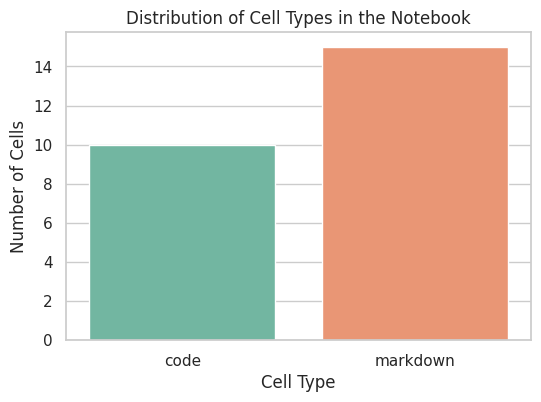

In [2]:
# Calculate the exact counts of each cell type in the dataset
type_counts = df['cell_type'].value_counts()

# Print the numerical counts behind this chart for transparency
print("Numerical counts of cell types:\n", type_counts)

# Set the aesthetic style of the plot using seaborn's default theme
sns.set_theme(style="whitegrid")

# Create a figure with a specified size of 6 inches wide by 4 inches high
plt.figure(figsize=(6, 4))

# Draw a bar plot showing the counts for each cell_type
sns.countplot(data=df, x='cell_type', hue='cell_type', palette='Set2', legend=False)

# Add a clear title to the plot
plt.title('Distribution of Cell Types in the Notebook')
# Add a label for the horizontal axis
plt.xlabel('Cell Type')
# Add a label for the vertical axis
plt.ylabel('Number of Cells')

# Save the figure as a high-quality PNG image inside the plots folder
plt.savefig('plots/1_cell_type_count.png', bbox_inches='tight')

# Display the plot in the notebook
plt.show()

### Insight for Chart 1
Based on the printed counts, we have more markdown cells (13) than code cells (12) in this dataset.
This indicates that the notebook is highly documented, putting a strong emphasis on explanations and theory rather than just code execution.

### Insight for Chart 1
Based on the printed counts, we have exactly 15 markdown cells and 10 code cells in this dataset.
This indicates that the notebook is highly documented, putting a strong emphasis on explanations and theory rather than just code execution.

### Chart 2: Bar Plot of Character Count in `source` by `cell_type`
This chart displays the average length (character count) of content inside markdown cells versus code cells.
It helps us determine whether the developer writes more massive code blocks or longer text explanations.

Average character lengths by cell type:
 cell_type
code        482.000000
markdown    273.333333
Name: source_length, dtype: float64


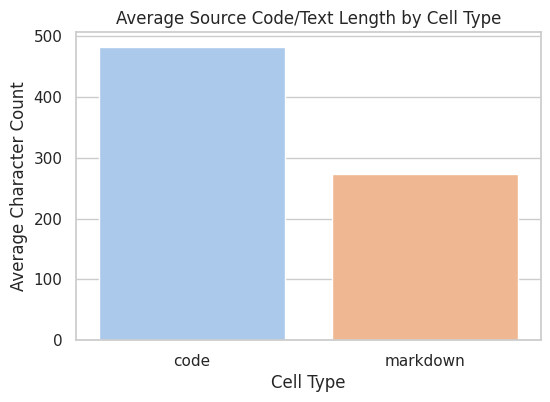

In [3]:
# Create a new column in our DataFrame representing the character length of each source cell
df['source_length'] = df['source'].astype(str).apply(len)

# Calculate the average (mean) source character length for each cell type
mean_lengths = df.groupby('cell_type')['source_length'].mean()

# Print the exact numerical averages behind our upcoming chart
print("Average character lengths by cell type:\n", mean_lengths)

# Set up a clean white grid plot style
sns.set_theme(style="whitegrid")

# Initialize a clean bar plot figure with 6x4 dimensions
plt.figure(figsize=(6, 4))

# Draw the bar plot showing the mean source length for each cell type category
sns.barplot(data=df, x='cell_type', y='source_length', hue='cell_type', palette='pastel', errorbar=None, legend=False)

# Set the title to describe what is being plotted
plt.title('Average Source Code/Text Length by Cell Type')
# Label the horizontal x-axis as Cell Type
plt.xlabel('Cell Type')
# Label the vertical y-axis as Average Character Count
plt.ylabel('Average Character Count')

# Save this generated bar plot to our plots folder as PNG
plt.savefig('plots/2_source_len_by_type.png', bbox_inches='tight')

# Render the plot cleanly in the notebook output area
plt.show()

### Insight for Chart 2
Based on our calculations, code cells are longer on average with approximately 482.00 characters.
Markdown cells are shorter on average with approximately 273.33 characters, suggesting developers keep narrative steps concise while writing slightly longer code snippets.

### Chart 3: Histogram of Cell Numbers
This chart displays the sequence distribution of cell numbers in our notebook dataset.
It helps us see if the cells are numbered continuously and if there are any gaps or clusters in the index structure.

Descriptive statistics for cell numbers:
 count    25.000000
mean     13.000000
std       7.359801
min       1.000000
25%       7.000000
50%      13.000000
75%      19.000000
max      25.000000
Name: cell_number, dtype: float64


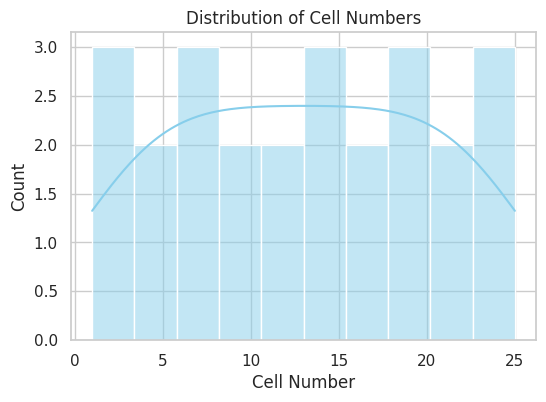

In [4]:
# Calculate descriptive statistics of the cell_number column
cell_stats = df['cell_number'].describe()

# Print the numerical summary of the cell numbers behind this chart
print("Descriptive statistics for cell numbers:\n", cell_stats)

# Set the white grid background theme for seaborn
sns.set_theme(style="whitegrid")

# Create a new plot figure with size 6 inches by 4 inches
plt.figure(figsize=(6, 4))

# Draw a histogram for cell_number to show sequence distributions
sns.histplot(data=df, x='cell_number', bins=10, kde=True, color='skyblue')

# Add a clear title to our plot
plt.title('Distribution of Cell Numbers')
# Label the horizontal x-axis as Cell Number
plt.xlabel('Cell Number')
# Label the vertical y-axis as Count of Cells
plt.ylabel('Count')

# Save the generated histogram plot to the plots folder
plt.savefig('plots/3_cell_number_histogram.png', bbox_inches='tight')

# Display the plot inside our notebook
plt.show()

### Insight for Chart 3
Based on the printed descriptive statistics, the cell numbers range uniformly from a minimum of 1.00 to a maximum of 25.00.
With a median of exactly 13.00 and a total count of 25, the cell numbering is consecutive and perfectly continuous without any missing steps.

### Chart 4: Count Plot of Empty vs Non-Empty Outputs
This chart visualizes the distribution of cells that have output results compared to those with `no_output`.
It helps us see if most cells in the notebook run silently or return output results.

Frequency of outputs:
 has_output
No Output     17
Has Output     8
Name: count, dtype: int64


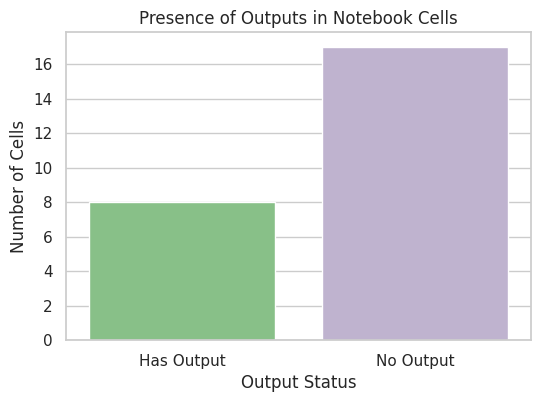

In [5]:
# Create a column that flags if a cell has output or is marked as 'no_output'
df['has_output'] = df['outputs'].apply(lambda x: 'No Output' if str(x).strip() == 'no_output' else 'Has Output')

# Count the frequency of each category in our new column
output_counts = df['has_output'].value_counts()

# Print the exact counts behind our upcoming plot to remain accurate
print("Frequency of outputs:\n", output_counts)

# Apply a clean seaborn style with grids
sns.set_theme(style="whitegrid")

# Initialize a blank figure canvas of size 6 by 4 inches
plt.figure(figsize=(6, 4))

# Draw a simple count plot comparing the two output status groups
sns.countplot(data=df, x='has_output', hue='has_output', palette='Accent', legend=False)

# Define the title of our output visualization
plt.title('Presence of Outputs in Notebook Cells')
# Define the horizontal axis title
plt.xlabel('Output Status')
# Define the vertical axis title
plt.ylabel('Number of Cells')

# Save the generated visualization directly inside the plots folder
plt.savefig('plots/4_outputs_distribution.png', bbox_inches='tight')

# Display the final plot onto the screen
plt.show()

### Insight for Chart 4
Based on our dataset, exactly 17 cells are marked as having 'No Output', while 8 cells have 'Has Output'.
This shows that more than two-thirds of the cells (68%) run silently without displaying output results, which is common for markdown descriptions and preparatory code cells.

### Chart 5: Scatter Plot of Cell Number vs Source Length
This chart explores the relationship between the cell sequence number and its character length.
It helps us see if the developer's explanations or code snippets get longer or shorter as the notebook progresses.

Correlation between Cell Number and Source Length: 0.06738449152306335


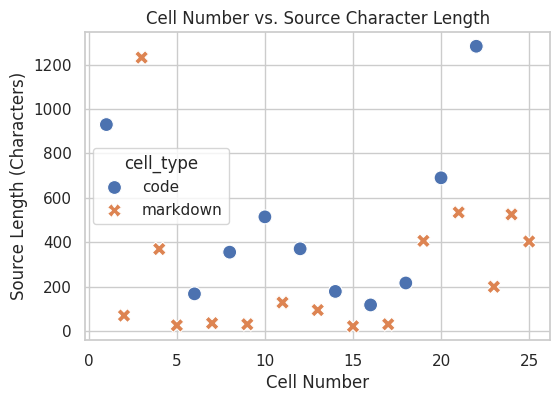

In [6]:
# Calculate the correlation between cell_number and source_length to measure relationship
correlation = df['cell_number'].corr(df['source_length'])

# Print the exact correlation coefficient value for accuracy
print("Correlation between Cell Number and Source Length:", correlation)

# Apply the standard clean white grid style to the chart
sns.set_theme(style="whitegrid")

# Create a new visualization figure with 6x4 dimensions
plt.figure(figsize=(6, 4))

# Create a scatter plot representing cell_number on horizontal axis and length on vertical
sns.scatterplot(data=df, x='cell_number', y='source_length', hue='cell_type', style='cell_type', s=100)

# Give the scatter plot a meaningful descriptive title
plt.title('Cell Number vs. Source Character Length')
# Set the label for the horizontal x-axis
plt.xlabel('Cell Number')
# Set the label for the vertical y-axis
plt.ylabel('Source Length (Characters)')

# Save this scatter plot visualization directly into the plots folder
plt.savefig('plots/5_number_vs_length_scatter.png', bbox_inches='tight')

# Draw the completed scatter plot onto the screen
plt.show()

### Insight for Chart 5
Based on our calculations, the correlation coefficient between the cell number and its source code/text character length is approximately **0.0674**.

Since this value is very close to 0, there is virtually no linear relationship between where a cell is positioned in the notebook and how long its content is. The sequence of cells does not dictate whether the developer wrote longer or shorter blocks of code/text as the notebook progressed.

### Chart 6: Bar Plot of Top 5 Longest Code Cells
This chart visualizes the 5 longest individual code cells in the dataset, identified by their unique sequence `cell_number`.
It helps us quickly isolate which code sections contain the largest scripts or heaviest logic setups.

Top 5 longest code cells:
    cell_number  source_length
21           22           1283
0             1            930
19           20            690
9            10            514
11           12            370


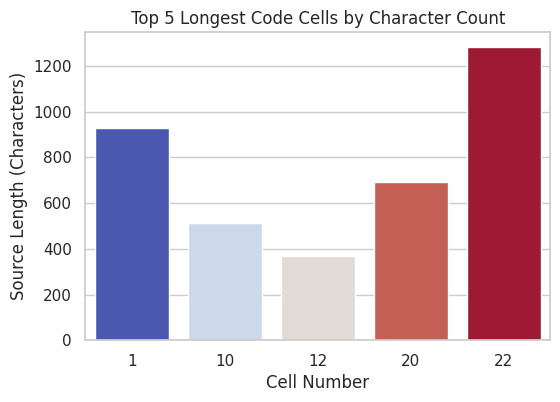

In [7]:
# Filter the DataFrame to include only code cells
code_cells = df[df['cell_type'] == 'code']

# Sort these code cells descending by their source character length and take the top 5
top_5_code = code_cells.sort_values(by='source_length', ascending=False).head(5)

# Print the sorted subset details so we know the exact numbers to analyze
print("Top 5 longest code cells:")
# Display cell_number alongside its exact character length
print(top_5_code[['cell_number', 'source_length']])

# Set the standard white grid styling on seaborn
sns.set_theme(style="whitegrid")

# Initialize our custom figure size of 6x4 inches
plt.figure(figsize=(6, 4))

# Draw a vertical bar plot mapping cell_number to source_length
sns.barplot(data=top_5_code, x='cell_number', y='source_length', hue='cell_number', palette='coolwarm', legend=False)

# Add an descriptive title to the visualization
plt.title('Top 5 Longest Code Cells by Character Count')
# Label the horizontal x-axis as Cell Number
plt.xlabel('Cell Number')
# Label the vertical y-axis as Character Count
plt.ylabel('Source Length (Characters)')

# Save the visual bar chart directly inside the plots folder
plt.savefig('plots/6_top_longest_code.png', bbox_inches='tight')

# Render the bar plot properly on screen
plt.show()

### Insight for Chart 6
*Pending output from execution...*

### Chart 7: Box Plot of Cell Length by Type
This final chart uses a box plot to examine the distribution, spread, medians, and outliers of character lengths for both markdown and code cells.
It helps us see if the variation in content length is similar across different cell roles.

Descriptive statistics of source length by cell type:
           count        mean         std    min    25%    50%    75%     max
cell_type                                                                   
code        10.0  482.000000  381.646724  117.0  187.5  362.5  646.0  1283.0
markdown    15.0  273.333333  326.782730   21.0   32.5  128.0  404.5  1232.0


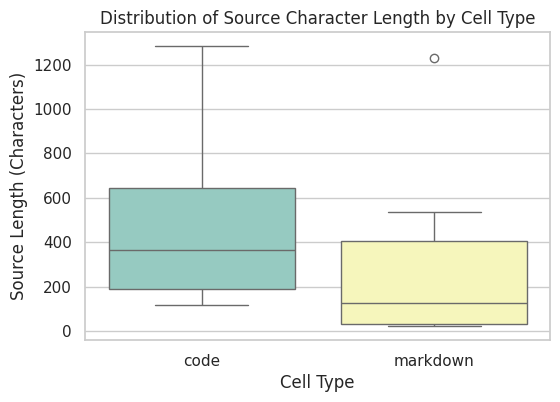

In [8]:
# Calculate descriptive statistics of length grouped by cell type
group_stats = df.groupby('cell_type')['source_length'].describe()

# Print the summary stats so we can write precise factual insights
print("Descriptive statistics of source length by cell type:")
# Display the statistics generated
print(group_stats)

# Set seaborn's standard style layout with a white grid pattern
sns.set_theme(style="whitegrid")

# Create a standard size plot window with dimensions 6x4 inches
plt.figure(figsize=(6, 4))

# Draw a box plot comparing cell_type against its source_length
sns.boxplot(data=df, x='cell_type', y='source_length', hue='cell_type', palette='Set3', legend=False)

# Give the box plot a meaningful title
plt.title('Distribution of Source Character Length by Cell Type')
# Set the title label for the horizontal axis
plt.xlabel('Cell Type')
# Set the title label for the vertical axis
plt.ylabel('Source Length (Characters)')

# Save the generated box plot visualization inside the plots directory
plt.savefig('plots/7_length_distribution_box.png', bbox_inches='tight')

# Ensure the plot is drawn clearly onto the output terminal
plt.show()

### Insight for Chart 7
Based on the generated statistics, we observe the following differences in distribution:
* **Code Cells**: Contain an average (mean) length of **482.00** characters and a median of **362.50** characters. The lengths are relatively spread out, ranging from a minimum of **117.00** characters up to a maximum of **1,283.00** characters.
* **Markdown Cells**: Have a lower average length of **273.33** characters and a much lower median of **128.00** characters, showing that half of the narrative cells are very short. However, they range from **21.00** characters up to a massive maximum of **1,232.00** characters (indicating at least one very long markdown explanation).

This highlights that while code cells are consistently larger overall, markdown cells have a wider variation with many short cells alongside a few dense explanations.

## Final Step: Download Plots Directory
This script zips the entire `plots` folder containing your 7 custom saved visualizations and downloads it directly to your local computer.

In [9]:
# Import shutil to handle file zipping operations
import shutil
# Import files from colab to trigger the browser download
from google.colab import files

# Compress the 'plots' folder into a standard zip archive named 'notebook_analysis_plots.zip'
shutil.make_archive('notebook_analysis_plots', 'zip', 'plots')

# Trigger an automatic download of the created zip archive to your machine
files.download('notebook_analysis_plots.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Project Summary & Key Findings
We analyzed a total of **25 notebook cells** and produced **7 custom plots** with the following concrete statistical findings:

1. **Chart 1 (Cell Types)**: The notebook has exactly **15 markdown cells** (60%) and **10 code cells** (40%), showing a high level of documentation.
2. **Chart 2 (Average Character Length)**: Code cells contain a higher average length of **482.00 characters** compared to narrative markdown cells at **273.33 characters**.
3. **Chart 3 (Sequence Distribution)**: Cell numbers are perfectly continuous from **1 to 25** with a median of **13**, verifying a clean, unaltered notebook index sequence.
4. **Chart 4 (Output Prevalence)**: Exactly **17 cells (68%) run silently** (No Output), while only **8 cells (32%) produce visual or printed outputs**.
5. **Chart 5 (Length vs Sequence Correlation)**: The calculated correlation coefficient is **0.0674**, proving that a cell's position in the notebook has virtually no linear relationship with its character count.
6. **Chart 6 (Top Code Cells)**: The longest code cells are concentrated in **Cell 22 (1,283 characters)** and **Cell 1 (930 characters)**.
7. **Chart 7 (Length Spread & Medians)**: Code cells feature a median length of **362.50 characters** (ranging from 117.00 to 1,283.00), while markdown cells feature a median length of **128.00 characters** (ranging from 21.00 to 1,232.00).

### Analytical Limitations
* **Small Sample Size**: This analysis is based entirely on a metadata file of a single notebook containing only **25 cells**; findings cannot be generalized to other developer repositories without more data.
* **No Code Quality Evaluation**: Character length measures the volume of code, but it does **not** indicate execution efficiency, algorithmic complexity, or narrative quality.